# Module 1 — Prétraitement des signatures TGA-FTIR

Objectifs de ce notebook :

1. inventorier les 30 fichiers CSV ;
2. attribuer automatiquement une famille de matériau à chaque fichier ;
3. distinguer les polymères de la cellulose ;
4. extraire et alléger les signatures spectrales ;
5. sauvegarder un dataset propre pour l'entraînement du modèle Deep Learning.

> Le fichier `PA7-Blank recovered` est conservé dans l'inventaire mais exclu de l'entraînement, car son statut est ambigu.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd()
if (cwd / 'data').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'data').exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Impossible de trouver le dossier 'data'. Lance Jupyter depuis le dossier hind."
    )

MODULE1_DIR = PROJECT_ROOT / 'data' / 'module1'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'module1'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

csv_files = sorted(MODULE1_DIR.glob('*.csv'))
print('Racine du projet :', PROJECT_ROOT)
print('Nombre de fichiers trouvés :', len(csv_files))

assert len(csv_files) == 30, f'30 fichiers attendus, {len(csv_files)} trouvés.'
print('✅ Les 30 fichiers du module 1 sont présents.')

Matplotlib is building the font cache; this may take a moment.


Racine du projet : C:\Users\elasr\OneDrive\Desktop\hind
Nombre de fichiers trouvés : 30
✅ Les 30 fichiers du module 1 sont présents.


## 1. Attribution automatique des familles

La famille est déduite du nom du fichier. Les variantes PE, LDPE et HDPE sont regroupées dans la famille `PE`. Les variantes PA6, PA66 et Nylon sont regroupées dans `PA`.

In [2]:
def detect_family(filename: str) -> str:
    name = filename.lower()

    if 'cellulose' in name:
        return 'CELLULOSE'
    if 'blank' in name:
        return 'AMBIGUOUS_BLANK'
    if 'teflon' in name:
        return 'PTFE'
    if 'pmma' in name:
        return 'PMMA'
    if 'pvc' in name:
        return 'PVC'
    if re.search(r'(^|\s)pet(\s|$)', name):
        return 'PET'
    if re.search(r'(^|\s)pp(\s|$)', name):
        return 'PP'
    if re.search(r'(^|\s)ps(\s|$)', name):
        return 'PS'
    if 'ldpe' in name or 'hdpe' in name or re.search(r'(^|\s)pe(\s|$)', name):
        return 'PE'
    if 'nylon' in name or re.search(r'(^|\s)pa\s*6(\s|$)', name) or re.search(r'(^|\s)pa\s*66(\s|$)', name):
        return 'PA'
    if re.search(r'(^|\s)pur(\s|$)', name):
        return 'PUR'
    if re.search(r'(^|\s)pc(\s|$)', name):
        return 'PC'

    return 'UNKNOWN'

records = []
for file in csv_files:
    family = detect_family(file.stem)
    if family == 'CELLULOSE':
        binary_label = 0
        binary_name = 'Non-plastique'
        use_for_binary = True
    elif family in {'AMBIGUOUS_BLANK', 'UNKNOWN'}:
        binary_label = np.nan
        binary_name = 'Ambigu / exclu'
        use_for_binary = False
    else:
        binary_label = 1
        binary_name = 'Polymère'
        use_for_binary = True

    header = pd.read_csv(file, nrows=0)
    row_count = sum(1 for _ in open(file, encoding='utf-8-sig', errors='ignore')) - 1

    records.append({
        'filename': file.name,
        'family': family,
        'binary_label': binary_label,
        'binary_name': binary_name,
        'use_for_binary': use_for_binary,
        'rows': row_count,
        'columns': len(header.columns)
    })

inventory = pd.DataFrame(records)
inventory

,filename,family,binary_label,binary_name,use_for_binary,rows,columns
0,DF_20230817 PE 20um 150-750C.csv,PE,1.0,Polymère,True,260,1664
1,DF_20230817 PP industrial 150-750C.csv,PP,1.0,Polymère,True,260,1664
2,DF_20230818 PET industrial 150-750C.csv,PET,1.0,Polymère,True,260,1664
3,DF_20230821 LDPE industrial 150-750C.csv,PE,1.0,Polymère,True,260,1664
4,DF_20230821 PS clear industrial 150-750C.csv,PS,1.0,Polymère,True,261,1664
5,DF_20230822 PMMA cospheric 150-750C.csv,PMMA,1.0,Polymère,True,261,1664
6,DF_20230822 Teflon 8000l 150-750C.csv,PTFE,1.0,Polymère,True,261,1664
7,DF_20230823 PUR industial 150-750C.csv,PUR,1.0,Polymère,True,261,1664
8,DF_20230823 PVC industrial 150-750C.csv,PVC,1.0,Polymère,True,260,1664
9,DF_20230823 Teflon 7A 150-750C.csv,PTFE,1.0,Polymère,True,261,1664


In [3]:
print('Répartition par famille :')
display(inventory.groupby('family').agg(
    fichiers=('filename', 'count'),
    lignes=('rows', 'sum')
).sort_values('fichiers', ascending=False))

unknown = inventory[inventory['family'] == 'UNKNOWN']
assert unknown.empty, f'Fichiers non reconnus : {unknown.filename.tolist()}'

inventory_path = RESULTS_DIR / 'inventaire_module1.csv'
inventory.to_csv(inventory_path, index=False, encoding='utf-8-sig')
print('\n✅ Inventaire sauvegardé dans :', inventory_path)

Répartition par famille :


,fichiers,lignes
family,,
PS,4,1042
PA,3,781
PE,3,781
PMMA,3,783
PP,3,775
PVC,3,782
PET,3,781
CELLULOSE,2,522
PTFE,2,522



✅ Inventaire sauvegardé dans : C:\Users\elasr\OneDrive\Desktop\hind\results\module1\inventaire_module1.csv


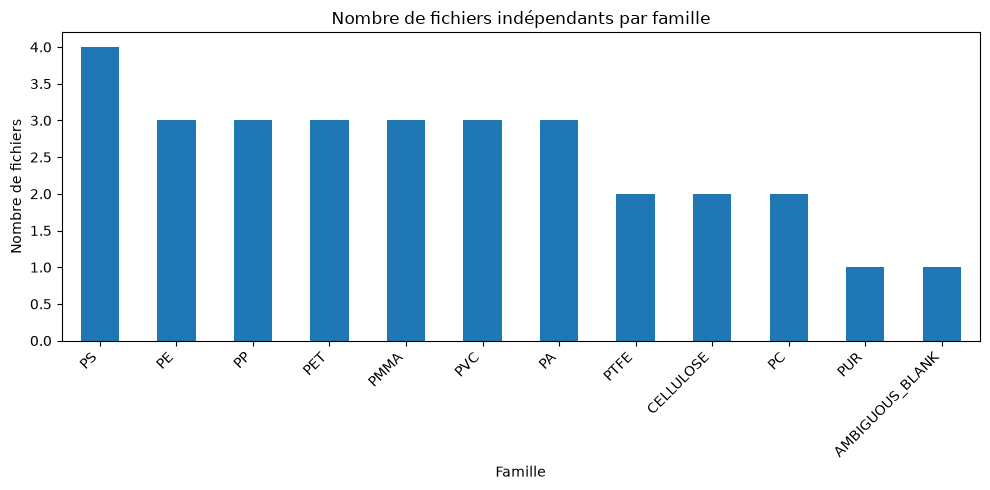

Figure sauvegardée dans : C:\Users\elasr\OneDrive\Desktop\hind\results\module1\repartition_fichiers_par_famille.png


In [4]:
family_counts = inventory['family'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
family_counts.plot(kind='bar')
plt.title('Nombre de fichiers indépendants par famille')
plt.xlabel('Famille')
plt.ylabel('Nombre de fichiers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

figure_path = RESULTS_DIR / 'repartition_fichiers_par_famille.png'
plt.savefig(figure_path, dpi=160, bbox_inches='tight')
plt.show()

print('Figure sauvegardée dans :', figure_path)

## 2. Détection des colonnes spectrales

Les quatre premières colonnes correspondent aux mesures TGA (`Temp`, `Gram-Schmidt`, `TG`, `DTG`). Les autres colonnes dont le nom est numérique correspondent aux nombres d'onde FTIR.

In [5]:
first_df = pd.read_csv(csv_files[0], nrows=5)

spectral_columns = []
wavenumbers = []

for col in first_df.columns:
    try:
        value = float(str(col).strip())
        if 700 <= value <= 4200:
            spectral_columns.append(col)
            wavenumbers.append(value)
    except ValueError:
        pass

wavenumbers = np.asarray(wavenumbers, dtype=np.float32)

print('Nombre total de colonnes :', len(first_df.columns))
print('Nombre de colonnes spectrales :', len(spectral_columns))
print('Axe spectral :', float(wavenumbers.min()), 'à', float(wavenumbers.max()), 'cm⁻¹')

assert len(spectral_columns) > 1000, 'Trop peu de colonnes spectrales détectées.'
print('✅ Colonnes spectrales détectées correctement.')

Nombre total de colonnes : 1664
Nombre de colonnes spectrales : 1660
Axe spectral : 800.3385009765625 à 3999.763916015625 cm⁻¹
✅ Colonnes spectrales détectées correctement.


## 3. Réduction légère de la dimension spectrale

Pour accélérer l'entraînement sur un ordinateur personnel, nous conservons une colonne spectrale sur quatre. Cette opération garde la forme générale de la signature tout en réduisant fortement le temps de calcul.

In [6]:
DOWNSAMPLE_STEP = 4
selected_spectral_columns = spectral_columns[::DOWNSAMPLE_STEP]
selected_wavenumbers = wavenumbers[::DOWNSAMPLE_STEP]

print('Colonnes spectrales initiales :', len(spectral_columns))
print('Colonnes spectrales conservées :', len(selected_spectral_columns))
print('Pas utilisé : une colonne sur', DOWNSAMPLE_STEP)

Colonnes spectrales initiales : 1660
Colonnes spectrales conservées : 415
Pas utilisé : une colonne sur 4


## 4. Construction du dataset binaire

- `1` : polymère / plastique ;
- `0` : cellulose / non-plastique ;
- le fichier ambigu contenant `Blank recovered` est exclu.

Chaque ligne conserve également le nom du fichier d'origine comme groupe. Ce groupe sera utilisé plus tard pour éviter de mettre des lignes du même fichier dans l'entraînement et dans le test.

In [7]:
X_parts = []
y_parts = []
family_parts = []
group_parts = []
temperature_parts = []

usable_inventory = inventory[inventory['use_for_binary']].copy()

for i, row in usable_inventory.iterrows():
    file = MODULE1_DIR / row['filename']
    df = pd.read_csv(file, usecols=['Temp'] + selected_spectral_columns)

    spectra = df[selected_spectral_columns].apply(pd.to_numeric, errors='coerce').to_numpy(dtype=np.float32)
    temperatures = pd.to_numeric(df['Temp'], errors='coerce').to_numpy(dtype=np.float32)

    finite_mask = np.isfinite(spectra).all(axis=1) & np.isfinite(temperatures)
    spectra = spectra[finite_mask]
    temperatures = temperatures[finite_mask]

    X_parts.append(spectra)
    y_parts.append(np.full(len(spectra), int(row['binary_label']), dtype=np.int8))
    family_parts.append(np.full(len(spectra), row['family'], dtype='<U30'))
    group_parts.append(np.full(len(spectra), row['filename'], dtype='<U120'))
    temperature_parts.append(temperatures)

    print(f"{row['filename'][:55]:55s} -> {row['family']:12s} | {len(spectra):3d} lignes")

X = np.concatenate(X_parts, axis=0)
y = np.concatenate(y_parts, axis=0)
families = np.concatenate(family_parts, axis=0)
groups = np.concatenate(group_parts, axis=0)
temperatures = np.concatenate(temperature_parts, axis=0)

print('\nDimensions finales de X :', X.shape)
print('Nombre de polymères :', int((y == 1).sum()))
print('Nombre de non-plastiques :', int((y == 0).sum()))
print('Nombre de fichiers indépendants :', len(np.unique(groups)))
print('Valeurs non finies restantes :', int((~np.isfinite(X)).sum()))

DF_20230817 PE 20um 150-750C.csv                        -> PE           | 260 lignes
DF_20230817 PP industrial 150-750C.csv                  -> PP           | 260 lignes
DF_20230818 PET industrial 150-750C.csv                 -> PET          | 260 lignes
DF_20230821 LDPE industrial 150-750C.csv                -> PE           | 260 lignes
DF_20230821 PS clear industrial 150-750C.csv            -> PS           | 261 lignes
DF_20230822 PMMA cospheric 150-750C.csv                 -> PMMA         | 261 lignes
DF_20230822 Teflon 8000l 150-750C.csv                   -> PTFE         | 261 lignes
DF_20230823 PUR industial 150-750C.csv                  -> PUR          | 261 lignes
DF_20230823 PVC industrial 150-750C.csv                 -> PVC          | 260 lignes
DF_20230823 Teflon 7A 150-750C.csv                      -> PTFE         | 261 lignes
DF_20231108 Nylon Flock 150-750C.csv                    -> PA           | 260 lignes
DF_20231108 PS Cospheric 150-750C.csv                   -> PS    

In [8]:
assert X.ndim == 2
assert len(X) == len(y) == len(groups) == len(families) == len(temperatures)
assert np.isfinite(X).all()
assert set(np.unique(y)) == {0, 1}

dataset_path = PROCESSED_DIR / 'module1_spectra_binary.npz'
np.savez_compressed(
    dataset_path,
    X=X,
    y=y,
    families=families,
    groups=groups,
    temperatures=temperatures,
    wavenumbers=selected_wavenumbers
)

print('✅ Dataset prétraité sauvegardé dans :')
print(dataset_path)
print('\nTaille de X :', X.shape)
print('Le fichier sera utilisé dans le notebook d’entraînement du 1D-CNN.')

✅ Dataset prétraité sauvegardé dans :
C:\Users\elasr\OneDrive\Desktop\hind\data\processed\module1_spectra_binary.npz

Taille de X : (7544, 415)
Le fichier sera utilisé dans le notebook d’entraînement du 1D-CNN.


## 5. Visualisation de signatures moyennes

Cette figure sert uniquement à vérifier visuellement que les familles présentent des signatures différentes.

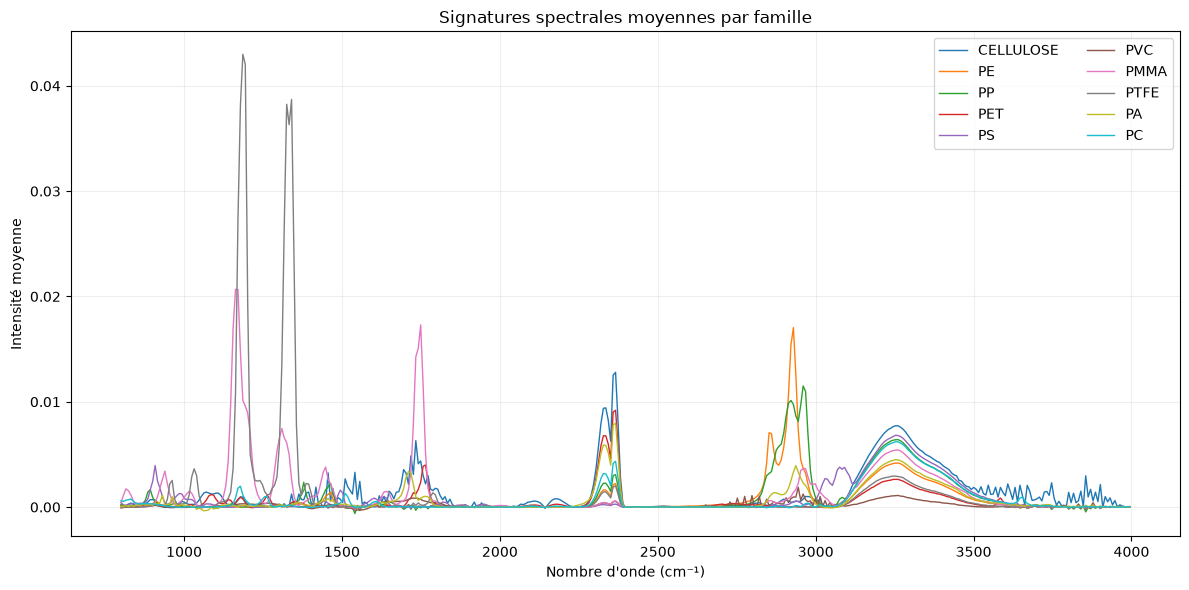

Figure sauvegardée dans : C:\Users\elasr\OneDrive\Desktop\hind\results\module1\signatures_moyennes_familles.png


In [9]:
plt.figure(figsize=(12, 6))

families_to_plot = ['CELLULOSE', 'PE', 'PP', 'PET', 'PS', 'PVC', 'PMMA', 'PTFE', 'PA', 'PC']
for family in families_to_plot:
    mask = families == family
    if mask.any():
        mean_spectrum = X[mask].mean(axis=0)
        plt.plot(selected_wavenumbers, mean_spectrum, label=family, linewidth=1)

plt.title('Signatures spectrales moyennes par famille')
plt.xlabel("Nombre d'onde (cm⁻¹)")
plt.ylabel('Intensité moyenne')
plt.legend(ncol=2)
plt.grid(alpha=0.2)
plt.tight_layout()

spectra_figure = RESULTS_DIR / 'signatures_moyennes_familles.png'
plt.savefig(spectra_figure, dpi=160, bbox_inches='tight')
plt.show()

print('Figure sauvegardée dans :', spectra_figure)

## Résultat attendu

À la fin, les fichiers suivants doivent exister :

- `results/module1/inventaire_module1.csv`
- `results/module1/repartition_fichiers_par_famille.png`
- `results/module1/signatures_moyennes_familles.png`
- `data/processed/module1_spectra_binary.npz`

Le dernier fichier contient les données propres qui serviront à entraîner le réseau 1D-CNN.